# Projet : Analyse Quantitative des Marchés Financiers

> **Auteur :** Afachtal Ahmed  
> **Date :** Mars 2026  

Les marchés financiers ne se comportent PAS comme une distribution normale. Les queues sont épaisses, la volatilité est persistante, et les chocs arrivent en clusters. Ce projet le démontre empiriquement.


##  Objectif

Ce projet explore les **propriétés statistiques des rendements financiers** à travers une analyse complète de quatre actifs majeurs :
-  **SPY** — ETF S&P 500 (marché actions US)
-  **DAX** — Indice boursier allemand
-  **AAPL** — Apple Inc.
-  **TSLA** — Tesla Inc.

##  Plan du Projet

1. Import des données & calcul des rendements log
2. Statistiques descriptives : µ, σ annualisés
3. Volatilité rolling (20j / 60j)
4. Volatilité EWMA (modèle RiskMetrics)
5. Distribution des rendements & QQ-Plot
6. Autocorrélation des rendements et de la variance
7. Matrice de corrélation inter-actifs



## 0️⃣ Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats


# Style 
plt.style.use('seaborn-v0_8-darkgrid')


## 1️⃣ Collecte des Données

On utilise **Yahoo Finance** pour télécharger les prix de clôture ajustés sur une période de 20 ans (2005–2026), ce qui couvre :
- La crise des subprimes (2008)
- La crise COVID (2020)
- Le bear market 2022 (inflation / Fed)

>  On utilise les **log-rendements** : `rt = ln(Pt / Pt-1)` car ils sont additifs dans le temps et mieux adaptés à la modélisation statistique.

In [2]:
# Téléchargement des données

tickers = ["SPY", "DAX", "AAPL", "TSLA"]
data = yf.download(tickers, start="2005-01-01", end="2026-01-01")["Close"]

print(f" Période : {data.index[0].date()} to {data.index[-1].date()}")
print(f" Nombre de jours de trading : {len(data):,}")
print("\n Aperçu des prix de clôture :")
data.tail(5)

 Période : 2005-01-03 to 2025-12-31
 Nombre de jours de trading : 5,283

 Aperçu des prix de clôture :


Ticker,AAPL,DAX,SPY,TSLA
Date,,,,
2025-12-24,273.554016,45.589863,690.380005,485.399994
2025-12-26,273.144409,45.699657,690.309998,475.190002
2025-12-29,273.504089,45.517002,687.849976,459.640015
2025-12-30,272.824707,45.869999,687.010010,454.429993
2025-12-31,271.605835,45.620998,681.919983,449.720001


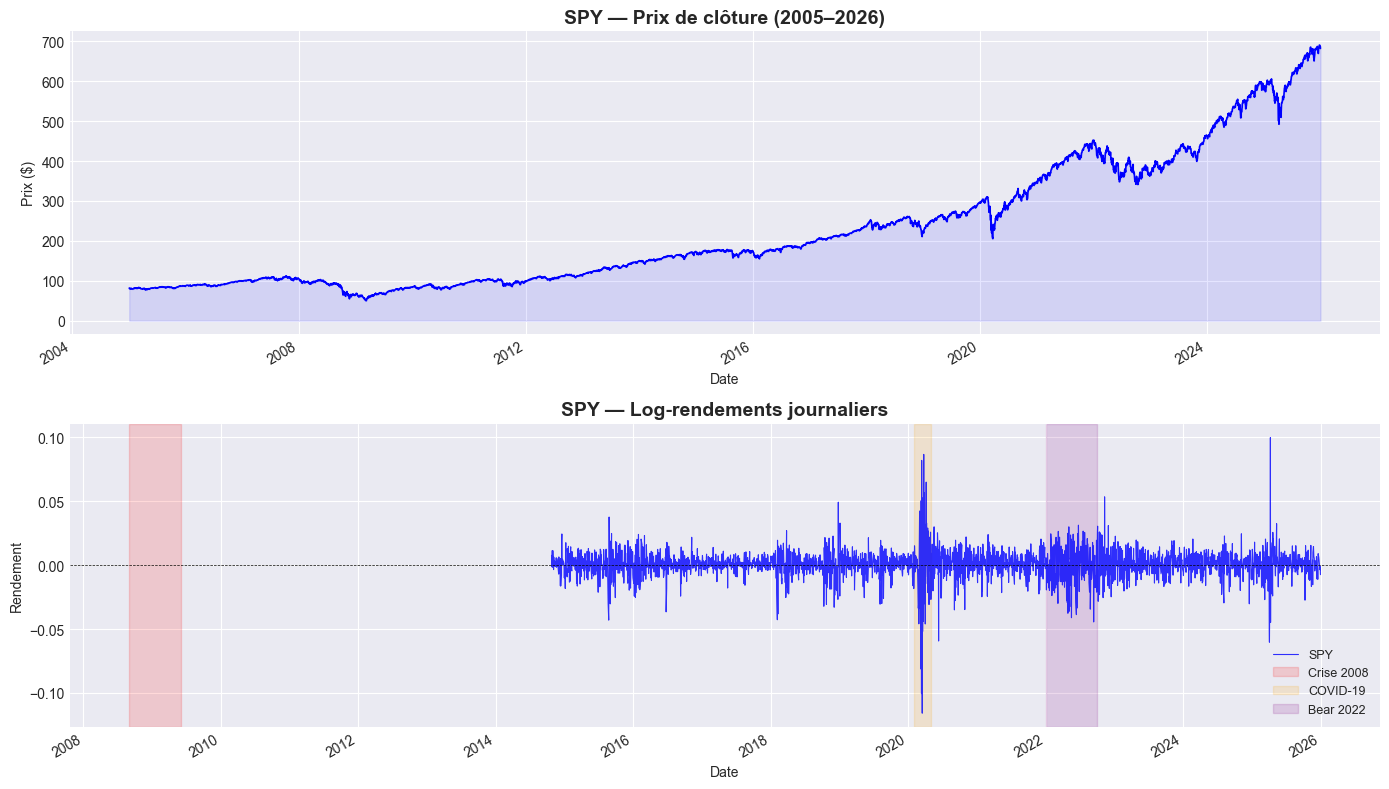

In [3]:
# Calcul des log-rendements journaliers:
returns = np.log(data / data.shift(1)).dropna()

# Visualisation : Prix & Rendements SPY
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

data["SPY"].plot(ax=axes[0], color="blue", linewidth=1.2)
axes[0].set_title("SPY — Prix de clôture (2005–2026)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Prix ($)")
axes[0].fill_between(data.index, data["SPY"], alpha=0.1, color="blue")

returns["SPY"].plot(ax=axes[1], color="blue", linewidth=0.8, alpha=0.8)
axes[1].set_title("SPY — Log-rendements journaliers", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Rendement")
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')

# visualization des crises
axes[1].axvspan('2008-09-01', '2009-06-01', alpha=0.15, color='red', label='Crise 2008')
axes[1].axvspan('2020-02-01', '2020-05-01', alpha=0.15, color='orange', label='COVID-19')
axes[1].axvspan('2022-01-01', '2022-10-01', alpha=0.15, color='purple', label='Bear 2022')
axes[1].legend(fontsize=9)

plt.tight_layout()

plt.show()


## 2 Statistiques Descriptives Annualisées

**Annualisation :**
- Rendement moyen : `µ_annuel = µ_journalier × 252`
- Volatilité : `σ_annuel = σ_journalier × √252`

On utilise **252 jours** car c'est le nombre moyen de jours de trading par an sur les marchés américains.

In [4]:
TRADING_DAYS = 252

# Tableau comparatif des statistiques 
stats_df = pd.DataFrame({
    'Rendement Annuel ': returns.mean() * TRADING_DAYS,
    'Volatilité Annuelle ': returns.std() * np.sqrt(TRADING_DAYS),
    'Ratio Sharpe ': (returns.mean() * TRADING_DAYS) / (returns.std() * np.sqrt(TRADING_DAYS)),
    'Skewness': returns.skew(),
    'Kurtosis': returns.kurtosis()
}).round(4)

print(" Statistiques annualisées des actifs :\n")
print(stats_df)
print("\n Observations :")
print(f"   SPY : rendement={stats_df.loc['SPY','Rendement Annuel ']:.1%}, vol={stats_df.loc['SPY','Volatilité Annuelle ']:.1%}")
print(f"  → TSLA : actif le plus volatile avec σ = {stats_df.loc['TSLA','Volatilité Annuelle ']:.1%}")
print(f"  → Kurtosis > 3 pour tous les actifs : queues épaisses (fat tails)")

 Statistiques annualisées des actifs :

        Rendement Annuel   Volatilité Annuelle   Ratio Sharpe   Skewness  \
Ticker                                                                     
AAPL               0.2207                0.2869         0.7692   -0.0901   
DAX                0.0753                0.2133         0.3530   -0.6370   
SPY                0.1293                0.1774         0.7290   -0.5824   
TSLA               0.3006                0.5737         0.5240   -0.0471   

        Kurtosis  
Ticker            
AAPL      6.3794  
DAX       9.2177  
SPY      14.6420  
TSLA      4.3727  

 Observations :
   SPY : rendement=12.9%, vol=17.7%
  → TSLA : actif le plus volatile avec σ = 57.4%
  → Kurtosis > 3 pour tous les actifs → queues épaisses (fat tails)


## 3️ Volatilité Rolling — Clustering de Volatilité

**Définition :** La volatilité rolling calcule l'écart-type des rendements sur une fenêtre glissante.

**Pourquoi deux fenêtres ?**
- **20 jours** (≈ 1 mois) : réactive, capte les chocs courts
- **60 jours** (≈ 3 mois) : plus lisse, indique la tendance de fond

>  **Observation attendue :** La volatilité n'est pas constante — elle arrive en **clusters**. Periods de calme suivies de tempêtes. C'est la base du modèle GARCH.

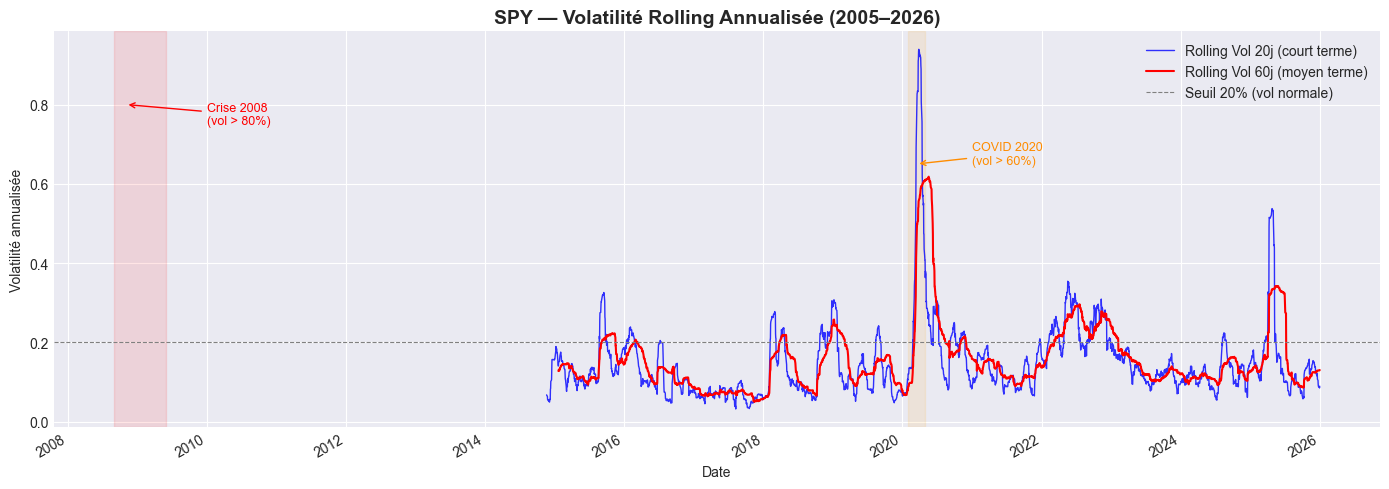

In [5]:
# Rolling Volatility
rolling_vol20 = returns["SPY"].rolling(20).std() * np.sqrt(TRADING_DAYS)
rolling_vol60 = returns["SPY"].rolling(60).std() * np.sqrt(TRADING_DAYS)

fig, ax = plt.subplots(figsize=(14, 5))

rolling_vol20.plot(ax=ax, label="Rolling Vol 20j (court terme)", color="blue", linewidth=1, alpha=0.8)
rolling_vol60.plot(ax=ax, label="Rolling Vol 60j (moyen terme)", color="red", linewidth=1.5)

# Zones de crise
ax.axvspan('2008-09-01', '2009-06-01', alpha=0.1, color='red')
ax.axvspan('2020-02-01', '2020-05-01', alpha=0.1, color='orange')
ax.axhline(0.20, color='gray', linestyle='--', linewidth=0.8, label='Seuil 20% (vol normale)')

ax.annotate('Crise 2008\n(vol > 80%)', xy=('2008-11-01', 0.80), fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red'),
            xytext=('2010-01-01', 0.75))
ax.annotate('COVID 2020\n(vol > 60%)', xy=('2020-03-15', 0.65), fontsize=9, color='darkorange',
            arrowprops=dict(arrowstyle='->', color='darkorange'),
            xytext=('2021-01-01', 0.65))

ax.set_title("SPY — Volatilité Rolling Annualisée (2005–2026)", fontsize=14, fontweight='bold')
ax.set_ylabel("Volatilité annualisée")
ax.legend()
plt.tight_layout()
plt.show()


## 4️ Volatilité EWMA — Modèle RiskMetrics (J.P. Morgan)

**EWMA** (Exponentially Weighted Moving Average) est le modèle de volatilité de **J.P. Morgan RiskMetrics** (1994).

**Formule :**
$$\sigma_t^2 = \lambda \cdot \sigma_{t-1}^2 + (1-\lambda) \cdot r_{t-1}^2$$

**Paramètre λ = 0.94** (valeur standard RiskMetrics pour données journalières)
- λ proche de 1 : longue mémoire, réagit lentement
- λ proche de 0 : courte mémoire, très réactif

> **Avantage vs Rolling :** L'EWMA donne plus de poids aux observations récentes, ce qui le rend plus réactif aux chocs de marché sans les effets de bord de la fenêtre fixe.

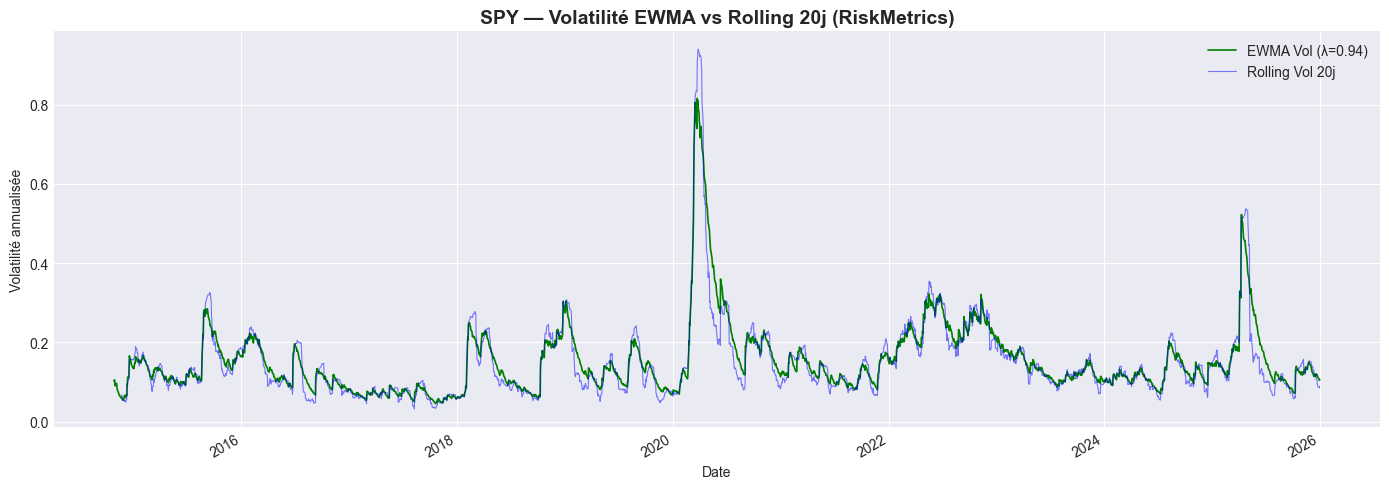

 Volatilité EWMA actuelle (dernier point) : 10.59%
 L'EWMA réagit plus vite que la rolling vol aux chocs car les observations récentes pèsent plus


In [6]:
# EWMA Volatility (RiskMetrics):
lamda = 0.94  # Paramètre RiskMetrics standard
ewma_var = returns["SPY"].ewm(alpha=1 - lamda).var()
ewma_vol = np.sqrt(ewma_var * TRADING_DAYS)

fig, ax = plt.subplots(figsize=(14, 5))

ewma_vol.plot(ax=ax, color="green", linewidth=1.2, label=f'EWMA Vol (λ={lamda})')
rolling_vol20.plot(ax=ax, color="blue", linewidth=0.8, alpha=0.5, label='Rolling Vol 20j')

ax.set_title("SPY — Volatilité EWMA vs Rolling 20j (RiskMetrics)", fontsize=14, fontweight='bold')
ax.set_ylabel("Volatilité annualisée")
ax.legend()

plt.tight_layout()
plt.show()

print(f" Volatilité EWMA actuelle (dernier point) : {ewma_vol.iloc[-1]:.2%}")
print(" L'EWMA réagit plus vite que la rolling vol aux chocs car les observations récentes pèsent plus")

## 5️ Distribution des Rendements & Fat Tails

**Hypothèse de normalité :** La théorie classique (Black-Scholes, Markowitz) suppose que les rendements suivent une loi normale.

**Réalité :** Les marchés présentent :
- **Skewness négatif** : les crashes sont plus fréquents que les euphories
- **Kurtosis > 3** → les événements extrêmes arrivent Beaucoup plus souvent que prédit par la normale (*fat tails*)

>  Les modèles de risque basés sur la normale sous-estiment systématiquement la probabilité des crises. C'est pourquoi Nassim Taleb parle de *"Black Swans"*.

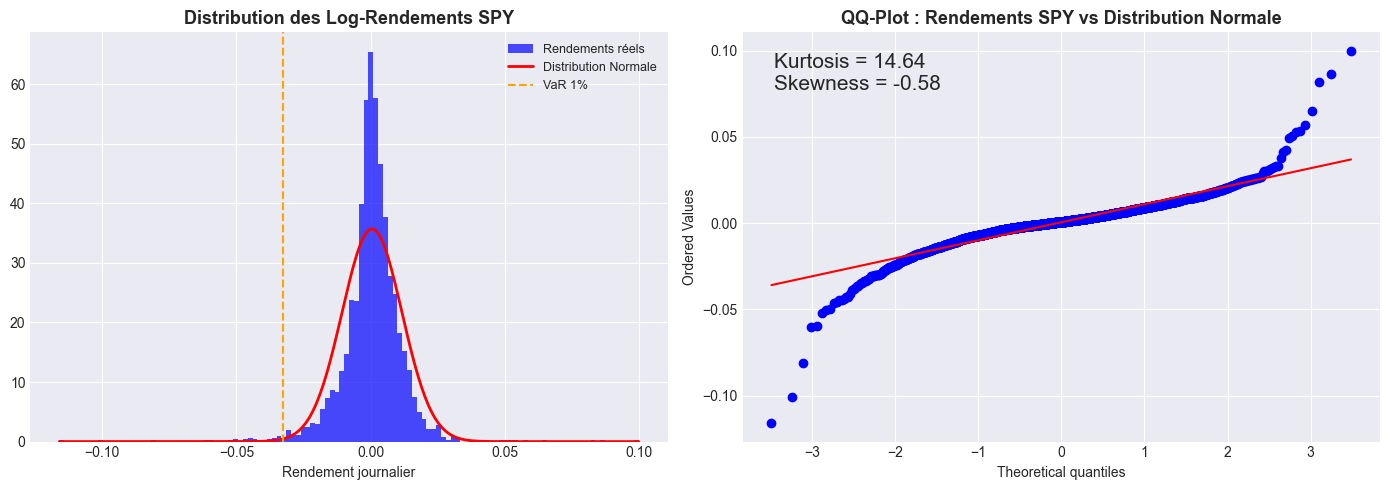


📊 Kurtosis SPY = 14.64 (Normale = 3.0)
📊 Skewness SPY = -0.5824
⚠️  Les queues réelles sont beaucoup plus épaisses que la normale : risque sous-estimé par Black-Scholes


In [7]:
#Distribution des rendements:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
ax = axes[0]
mu_spy = returns["SPY"].mean()
sigma_spy = returns["SPY"].std()

returns["SPY"].hist(bins=120, ax=ax, density=True, color="blue", alpha=0.7, label='Rendements réels')

x = np.linspace(returns["SPY"].min(), returns["SPY"].max(), 350)
ax.plot(x, stats.norm.pdf(x, mu_spy, sigma_spy), 'r-', linewidth=2, label='Distribution Normale')

ax.axvline(returns["SPY"].quantile(0.01), color='orange', linestyle='--', linewidth=1.5, label='VaR 1%')
ax.set_title("Distribution des Log-Rendements SPY", fontsize=13, fontweight='bold')
ax.set_xlabel("Rendement journalier")
ax.legend(fontsize=9)

# QQ Plot
ax = axes[1]
stats.probplot(returns["SPY"], dist="norm", plot=ax)

ax.set_title("QQ-Plot : Rendements SPY vs Distribution Normale", fontsize=13, fontweight='bold')
        
# Kurtosis / Skewness
kurt = returns["SPY"].kurtosis()
skew = returns["SPY"].skew()
ax.text(0.05, 0.95, f'Kurtosis = {kurt:.2f}\nSkewness = {skew:.2f}', 
        transform=ax.transAxes, verticalalignment='top', fontsize=15)

plt.tight_layout()
plt.show()

print(f"\n Kurtosis SPY = {kurt:.2f} (Normale = 3.0)")
print(f" Skewness SPY = {skew:.4f}")
print(" Les queues réelles sont beaucoup plus épaisses que la normale : risque sous-estimé par Black-Scholes")

## 6️ Autocorrélation — Mémoire des Marchés

**Tests :**
1. **ACF des rendements** → Teste si les rendements passés prédisent les futurs (efficience des marchés)
2. **ACF des rendements²** → Teste la persistance de la **variance** (clustering de volatilité)

**Résultats attendus :**
- Rendements : peu ou pas d'autocorrélation (marchés relativement efficients)
- Rendements² : forte autocorrélation (la volatilité est persistante (effet ARCH/GARCH) )

> 

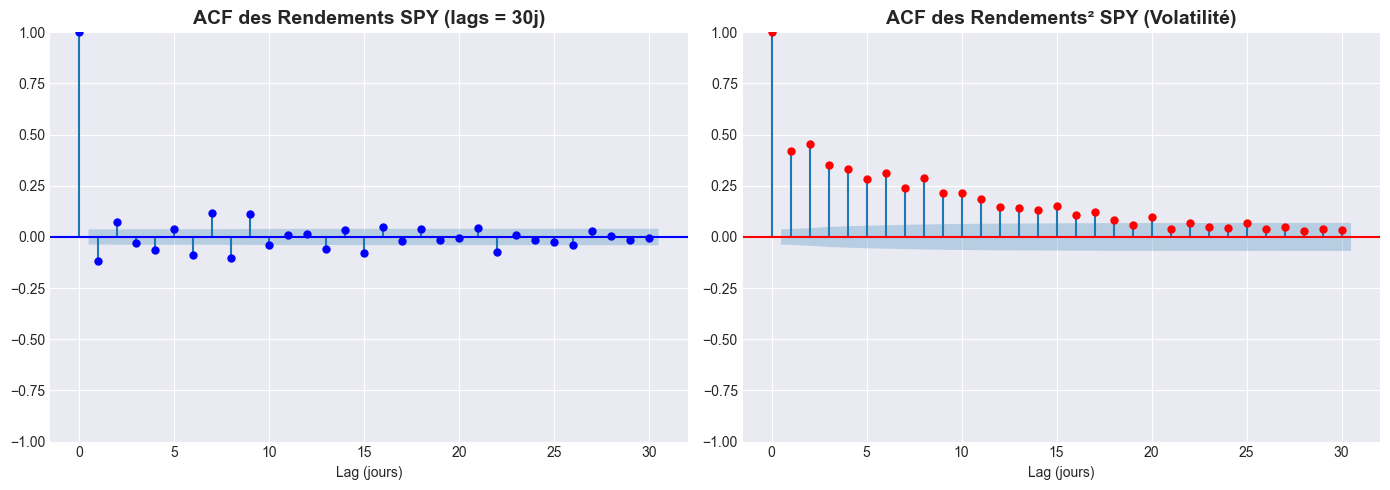

Conclusion : Les rendements sont peu prévisibles MAIS leur variance l'est (clustering) 
 C'est le fondement des modèles GARCH pour la prévision de risque.


In [8]:
# Autocorrélation :
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(returns["SPY"], lags=30, ax=axes[0], color="blue")
axes[0].set_title("ACF des Rendements SPY (lags = 30j)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Lag (jours)")


plot_acf(returns["SPY"]**2, lags=30, ax=axes[1], color="red")
axes[1].set_title("ACF des Rendements² SPY (Volatilité)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Lag (jours)")

plt.tight_layout()
plt.show()

print("Conclusion : Les rendements sont peu prévisibles MAIS leur variance l'est (clustering) ")
print(" C'est le fondement des modèles GARCH pour la prévision de risque.")

## 7️ Matrice de Corrélation Inter-Actifs

**Pourquoi c'est crucial pour la gestion de portefeuille ?**

La diversification fonctionne uniquement si les actifs ne sont pas parfaitement corrélés. En théorie de Markowitz :
$$\sigma_p^2 = w^T \Sigma w$$

Plus les corrélations sont faibles, plus on peut réduire le risque du portefeuille à rendement égal.

> Les corrélations augmentent fortement pendant les crises ("correlation goes to 1 in a crisis"). La diversification disparaît quand on en a le plus besoin.

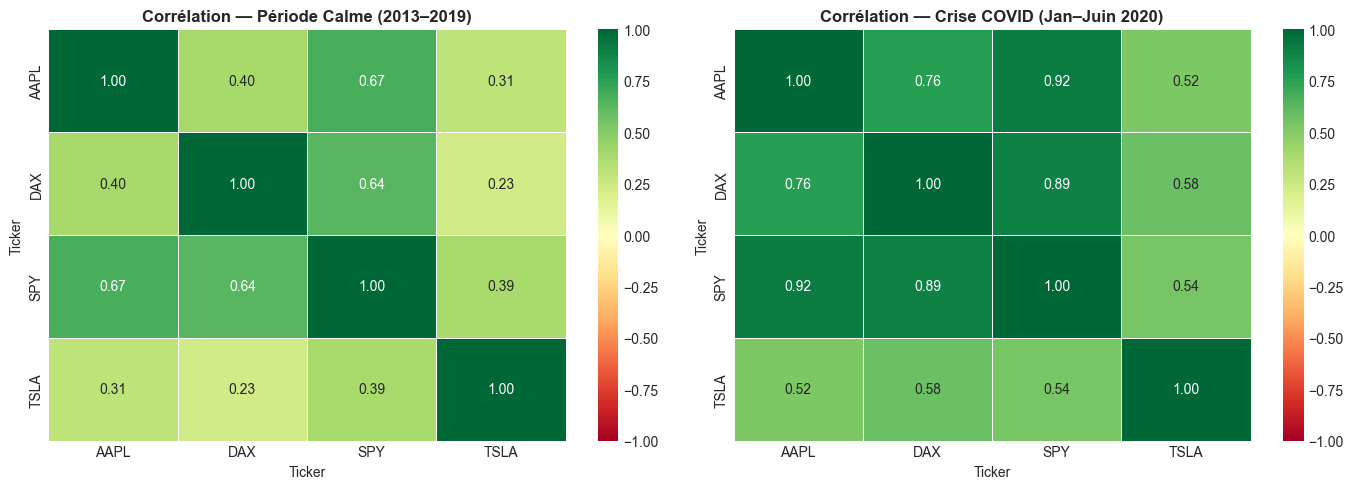

Corrélation globale (SPY:AAPL) :
   Période calme : 0.67
   Crise COVID   : 0.92

 Les corrélations augmentent en crise : la diversification disparaît quand on en a le plus besoin !


In [9]:
# Matrice de Corrélation :
corr_matrix = returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Corrélation période normale (2013-2019)
corr_normal = returns.loc['2013':'2019'].corr()
sns.heatmap(corr_normal, annot=True, fmt='.2f', cmap='RdYlGn', 
            vmin=-1, vmax=1, ax=axes[0], linewidths=0.5)
axes[0].set_title("Corrélation — Période Calme (2013–2019)", fontsize=12, fontweight='bold')

# Corrélation période de crise (COVID 2020)
corr_crisis = returns.loc['2020-01':'2020-06'].corr()
sns.heatmap(corr_crisis, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, ax=axes[1], linewidths=0.5)
axes[1].set_title("Corrélation — Crise COVID (Jan–Juin 2020)", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Corrélation globale (SPY:AAPL) :")
print(f"   Période calme : {corr_normal.loc['SPY','AAPL']:.2f}")
print(f"   Crise COVID   : {corr_crisis.loc['SPY','AAPL']:.2f}")
print("\n Les corrélations augmentent en crise : la diversification disparaît quand on en a le plus besoin !")


"The stock market is a device for transferring money from the impatient to the patient."*  
— Warren Buffett



